In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from torch import optim
import torch
import numpy as np

## Real cummulative log-returns

In [3]:
from library.dataset import get_pytorch_datataset, BATCH_SIZE

df_returns_real, dataset, dataloader, N_ASSETS, WINDOW_SIZE = get_pytorch_datataset()

print(f'\nDataset length: {len(dataset)}')
print(f'Number of assets: {N_ASSETS}')
sample_batch = next(iter(dataloader))
assert sample_batch.size() == (BATCH_SIZE, N_ASSETS, WINDOW_SIZE)
print(f'Sample batch: {sample_batch.size()}')

AAAAAAA data True data\tickers.csv True
Chosen tickers: ['LKOH', 'SBER', 'SBERP', 'VTBR', 'MOEX']
Length before dropping NaNs: 2603
Length after dropping NaNs: 2577

Dataset length: 2217
Number of assets: 5
Sample batch: torch.Size([256, 5, 360])


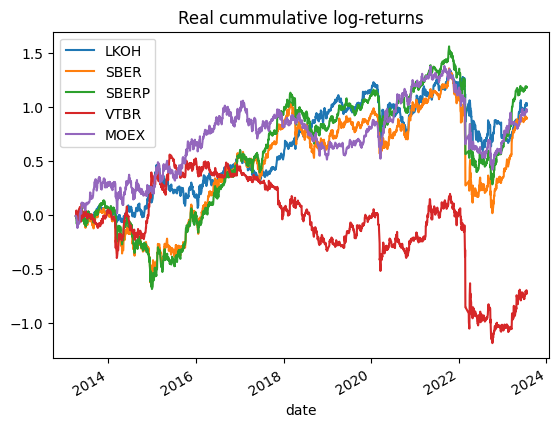

In [27]:
df_returns_real.cumsum().plot(title='Real cummulative log-returns')
plt.show()

## Cumulative log-returs generated by different architectures

In [5]:
import os
os.chdir("..")
print(os.getcwd(), os.listdir())

C:\Users\an.v.potapov\Desktop\учеба\ФТИАД\курсач\gan_moex ['.git', '.gitignore', '.idea', '.ipynb_checkpoints', '.pytest_cache', 'AIRI', 'Autocorrelation_for_LKOH_GRU.png', 'Autocorrelation_for_LKOH_LSTM.png', 'Autocorrelation_for_LKOH_TCN.png', 'Autocorrelation_for_MOEX_GRU.png', 'Autocorrelation_for_MOEX_LSTM.png', 'Autocorrelation_for_MOEX_TCN.png', 'Autocorrelation_for_SBERP_GRU.png', 'Autocorrelation_for_SBERP_LSTM.png', 'Autocorrelation_for_SBERP_TCN.png', 'Autocorrelation_for_SBER_GRU.png', 'Autocorrelation_for_SBER_LSTM.png', 'Autocorrelation_for_SBER_TCN.png', 'Autocorrelation_for_VTBR_GRU.png', 'Autocorrelation_for_VTBR_LSTM.png', 'Autocorrelation_for_VTBR_TCN.png', 'compare with airi', 'dashboard', 'data', 'fingan', 'genrisk', 'Interactive_dashboard_ECML_2025', 'library', 'lightning_logs', 'README.MD', 'research', 'setup.py', 'TSGBench', 'wandb']


In [13]:
lstm_df_returns_fake = np.load('Interactive_dashboard_ECML_2025/generated_returns/lstm_df_returns_fake.npy')
gru_df_returns_fake = np.load('Interactive_dashboard_ECML_2025/generated_returns/gru_df_returns_fake.npy')
tcn_df_returns_fake = np.load('Interactive_dashboard_ECML_2025/generated_returns/tcn_df_returns_fake.npy')


In [14]:

ARCHITECTURES = ['TCN', 'LSTM', 'GRU']
GENERATIONS_AMOUNT = 20
generated_returns = {arch: [] for arch in ARCHITECTURES}

In [15]:
import pandas as pd
generated_returns['LSTM'] = [pd.DataFrame({tic: lstm_df_returns_fake[i][:, n] for n, tic in zip(range(5), df_returns_real.columns)}, index=df_returns_real.index) for i in range(GENERATIONS_AMOUNT)]
generated_returns['GRU'] = [pd.DataFrame( {tic: gru_df_returns_fake[i][:, n] for n, tic in zip(range(5), df_returns_real.columns)}, index=df_returns_real.index) for i in range(GENERATIONS_AMOUNT)]
generated_returns['TCN'] = [pd.DataFrame( {tic: tcn_df_returns_fake[i][:, n] for n, tic in zip(range(5), df_returns_real.columns)}, index=df_returns_real.index) for i in range(GENERATIONS_AMOUNT)]



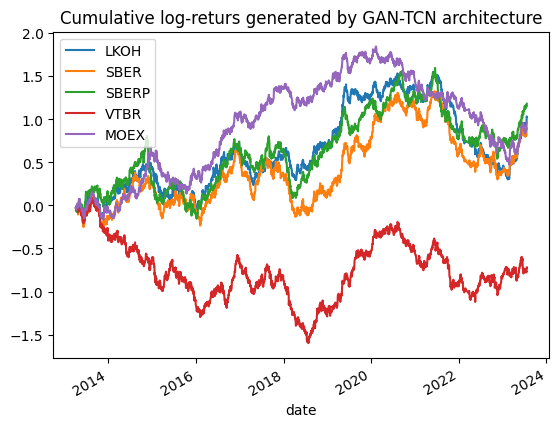

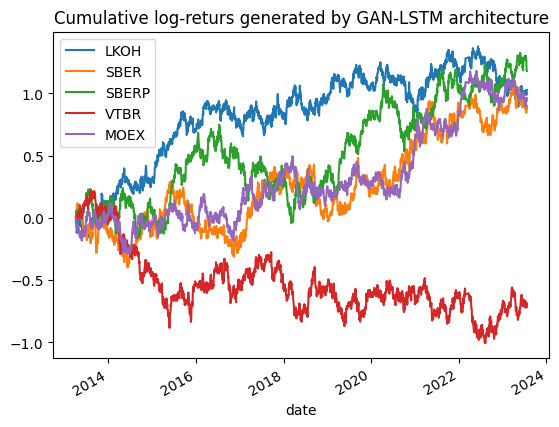

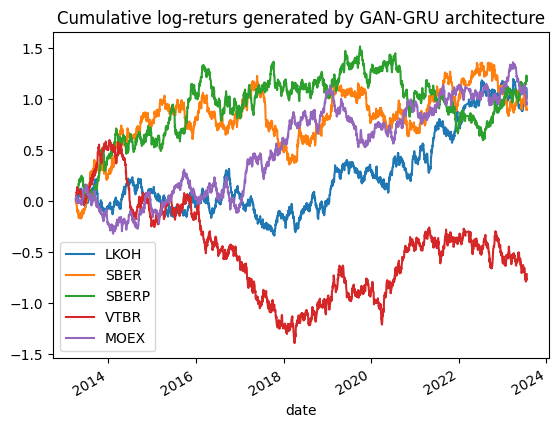

In [25]:
for arch in ARCHITECTURES:
    generated_returns[arch][0].cumsum().plot(title=f'Cumulative log-returs generated by GAN-{arch} architecture')

# Metrics for assessing the quality of generations

## Autocorrelation

In [20]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from statsmodels.tsa.stattools import acf
import numpy as np
from scipy.stats import norm


def ACF(arcitecture, df_returns_fakes):
    # Предполагаем, что df_returns_real и df_returns_fake имеют одинаковые колонки
    columns = df_returns_real.columns
    
    # Создаем subplot для каждой колонки
    # fig, axes = plt.subplots(len(columns), 1, figsize=(12, 6*len(columns)))
    # if len(columns) == 1:
    #     axes = [axes]  # Чтобы работало с одной колонкой
    
    # Параметры
    max_lag = 500  # Максимальный лаг для отображения
    confidence = 0.95
    alpha = 1 - confidence
    z_crit = norm.ppf(1 - alpha / 2)  # ≈1.96 для 95% ДИ
    
    for i, col in enumerate(columns):
        # Вычисляем автокорреляцию и доверительные интервалы для реальных данных
        acf_fakes = []
        for df_returns_fake in df_returns_fakes:
            acf_fakes.append(acf(np.abs(df_returns_fake[col]), nlags=max_lag, alpha=alpha, fft=False)[0])
        acf_fakes = np.array(acf_fakes)
        acf_fake = acf_fakes.mean(axis=0)
        
        # Вычисляем автокорреляцию для фейковых данных
        acf_real = acf(np.abs(df_returns_real[col]), nlags=max_lag, fft=False)
    
        # доверительный интервал
        # Среднее и стандартное отклонение по реализациям (для каждой временной точки)
        mean = np.mean(acf_fakes, axis=0)
        std = np.std(acf_fakes, axis=0, ddof=1)  # ddof=1 для несмещённой оценки
        
        # Критическое значение z для 95% доверительного интервала
        
        # Доверительный интервал
        margin_of_error = z_crit * std / np.sqrt(len(df_returns_fakes))
        ci_lower = mean - margin_of_error
        ci_upper = mean + margin_of_error
    
        
        # Лаги для оси X
        lags = np.arange(max_lag + 1)
        
        # График для реальных данных с доверительным интервалом
        figure(figsize=(8, 6), dpi=100)
        plt.plot(lags, acf_fake, label='Fake Data')
        # График для фейковых данных
        plt.plot(lags, acf_real, label='Real Data')
        plt.fill_between(
            range(acf_fake.shape[0]),
            ci_lower,
            ci_upper,
            color='blue',
            alpha=0.2,
            label='95% доверительный интервал'
        )
        plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        plt.title(f'Autocorrelation for {col} ({arcitecture})', fontsize=14)
        plt.xlabel('Lag')
        plt.ylabel('Autocorrelation')
        plt.ylim(-0.1, 0.3)
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.savefig(f'Autocorrelation_for_{col}_{arcitecture}.png')
        # plt.show()
    
    # plt.tight_layout()
    # plt.show()


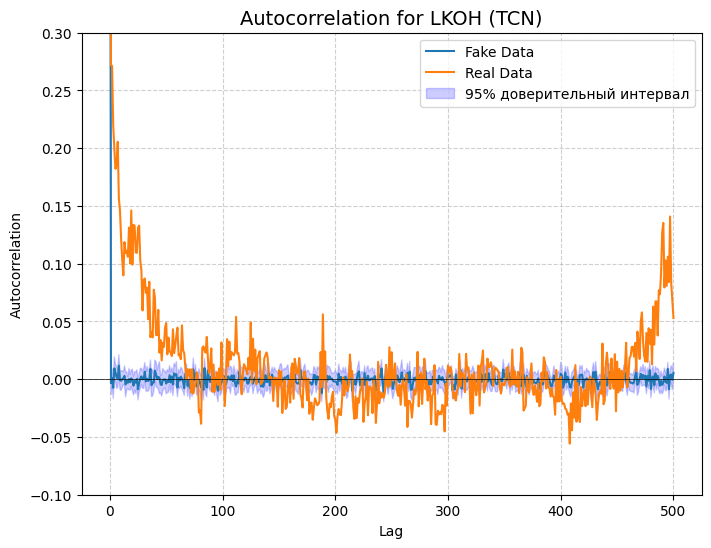

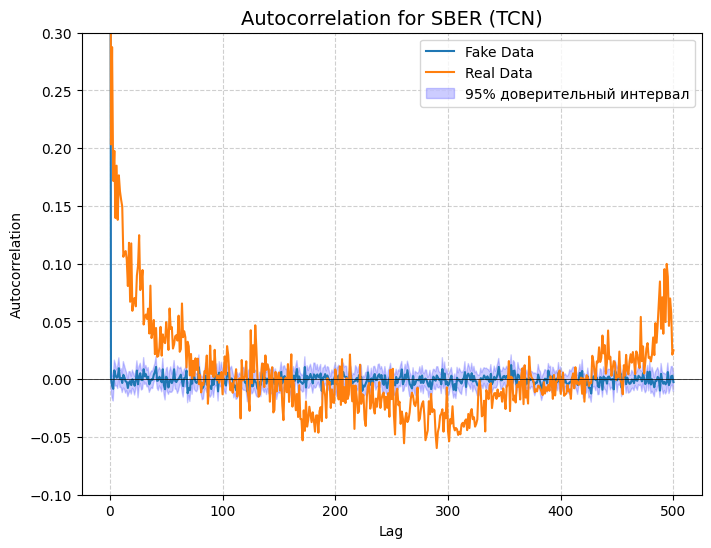

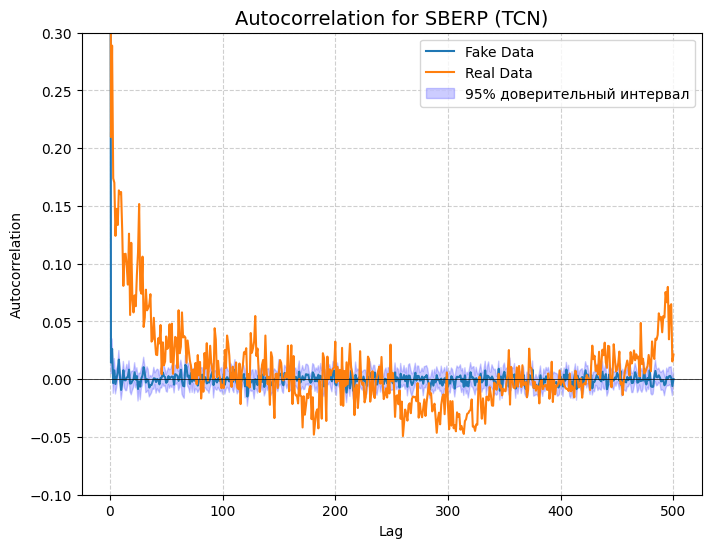

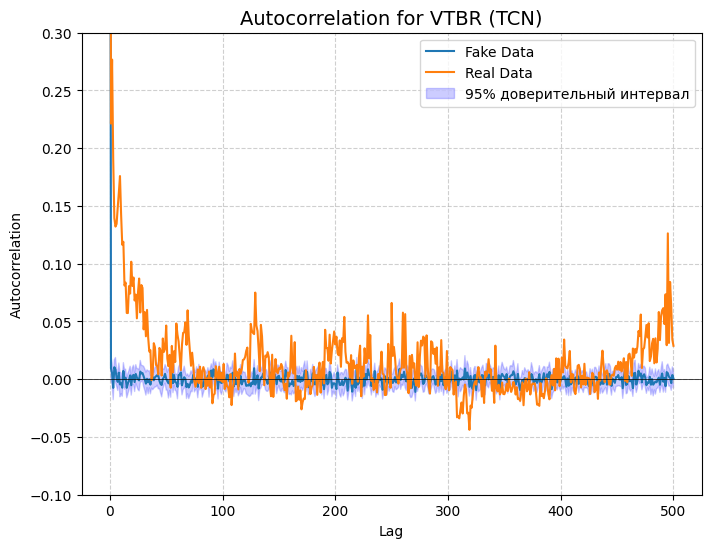

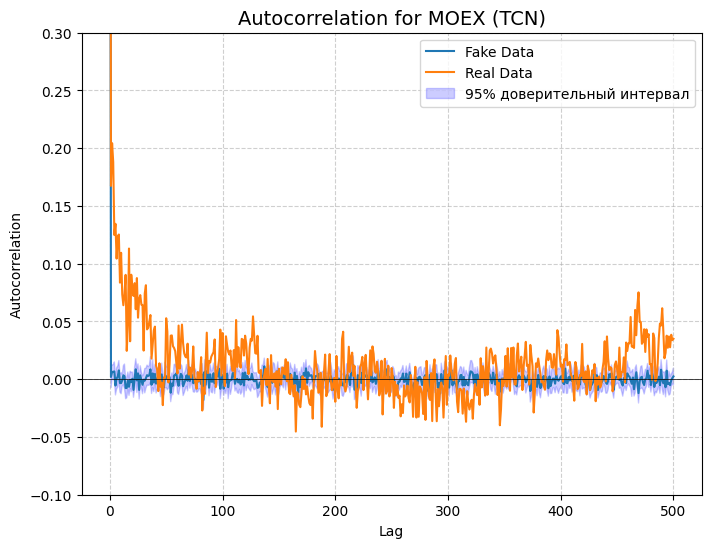

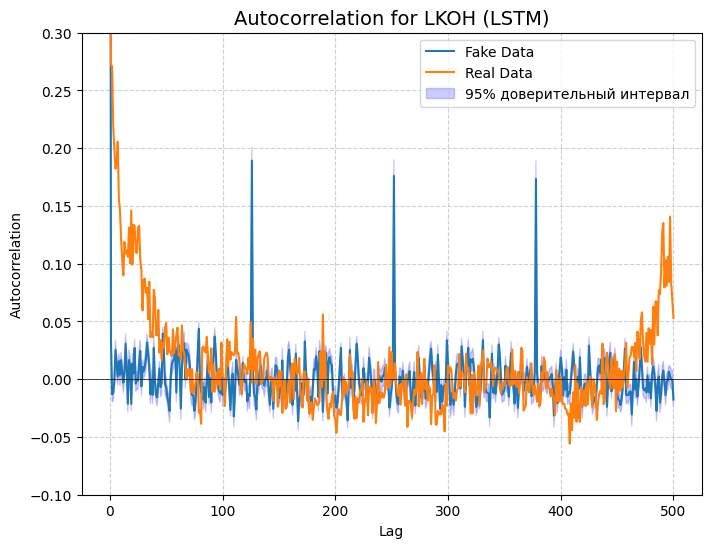

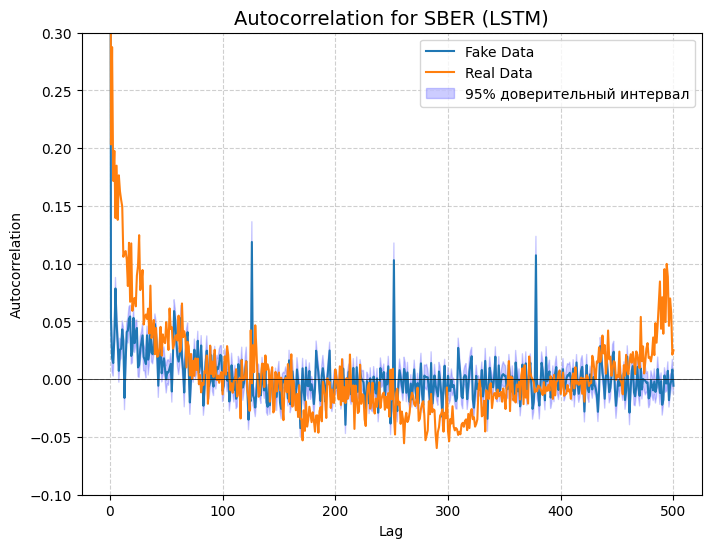

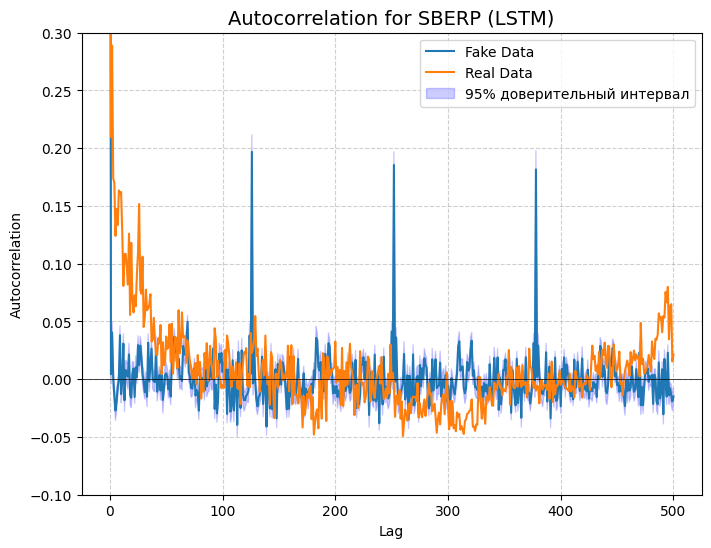

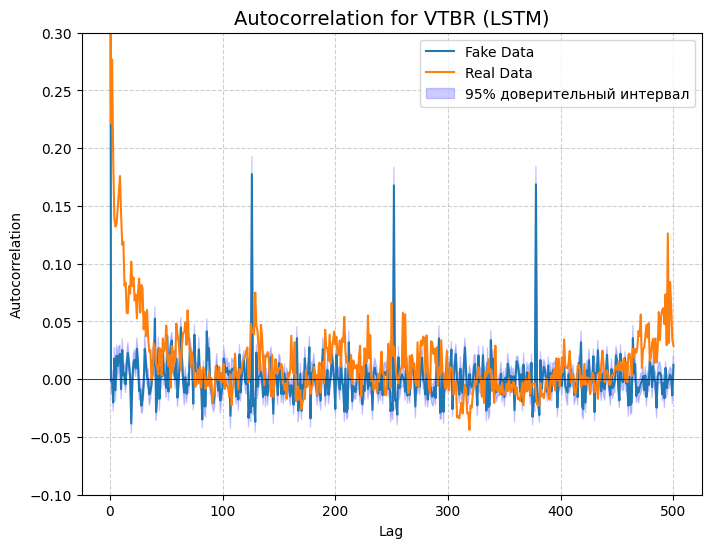

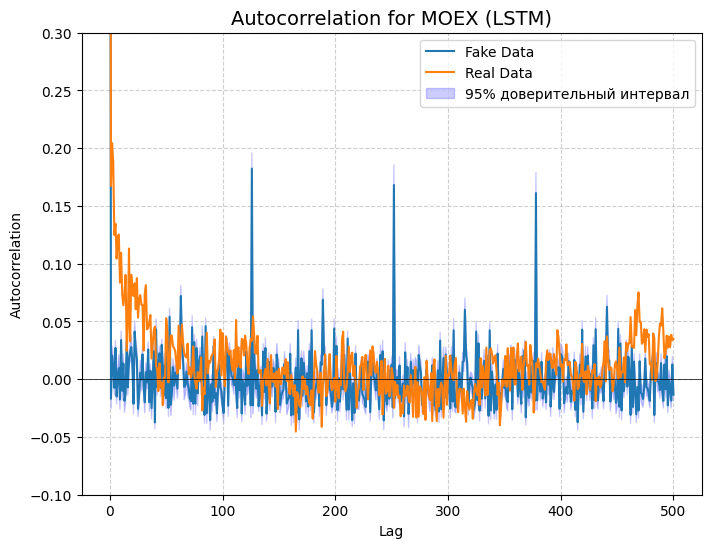

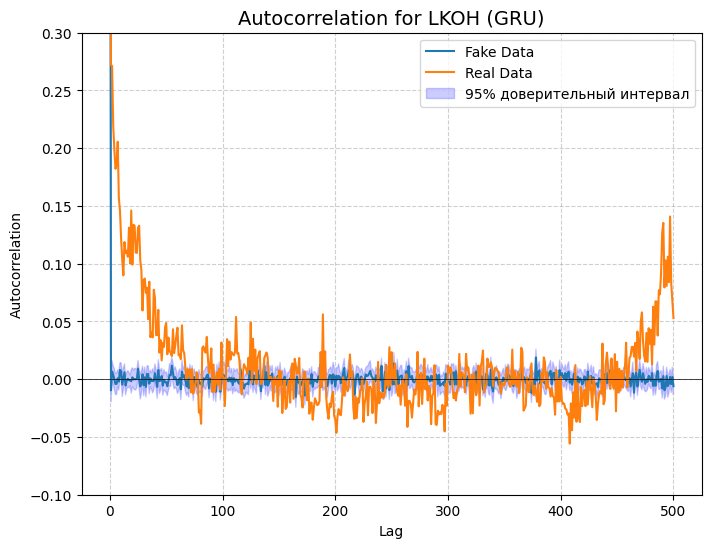

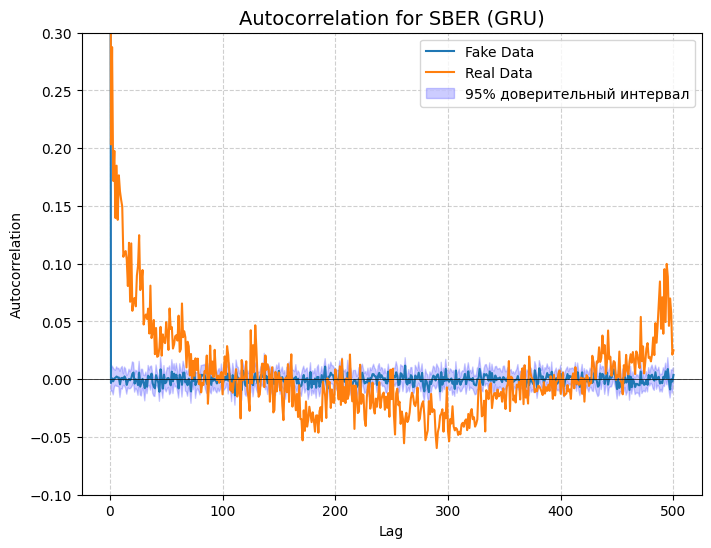

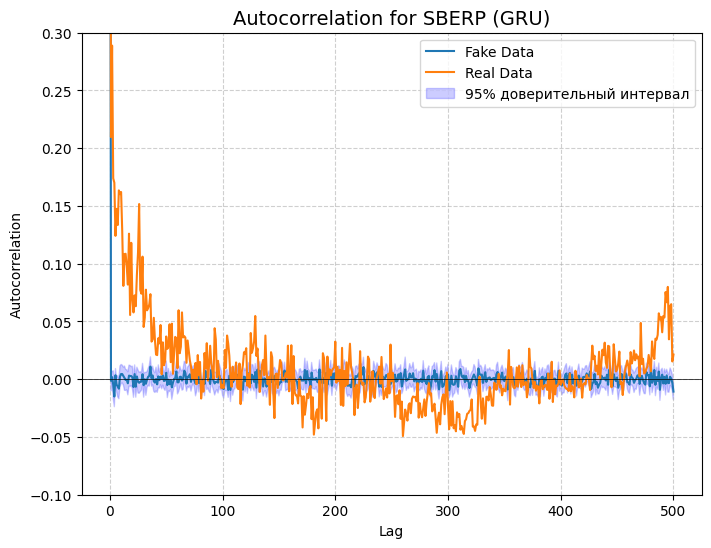

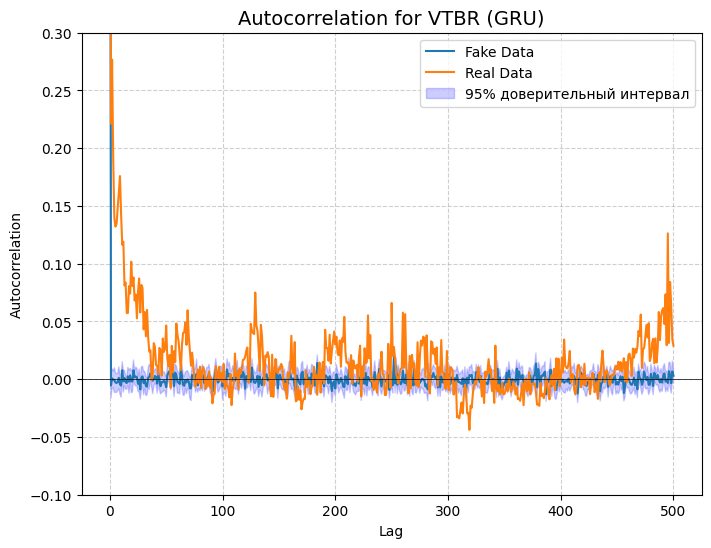

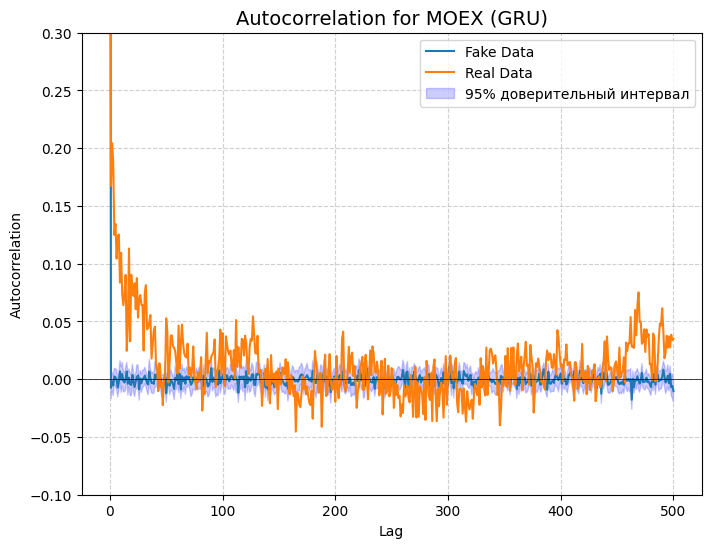

In [21]:
for arch in ARCHITECTURES:
    ACF(arch, generated_returns[arch])

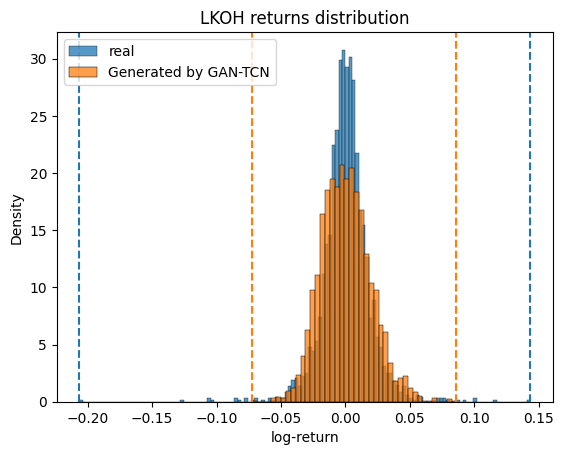

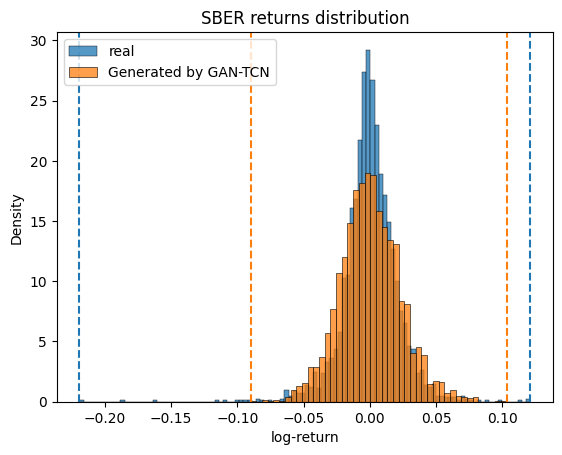

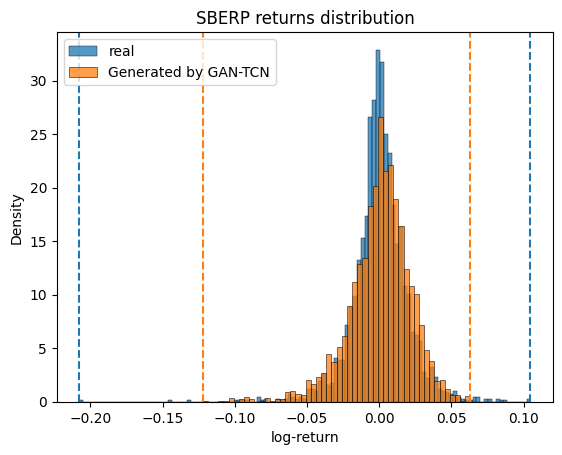

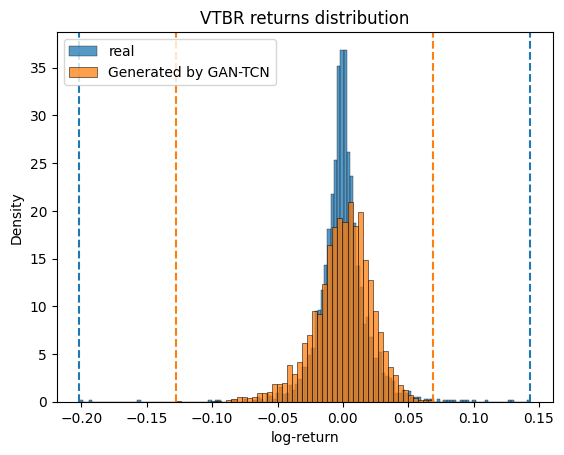

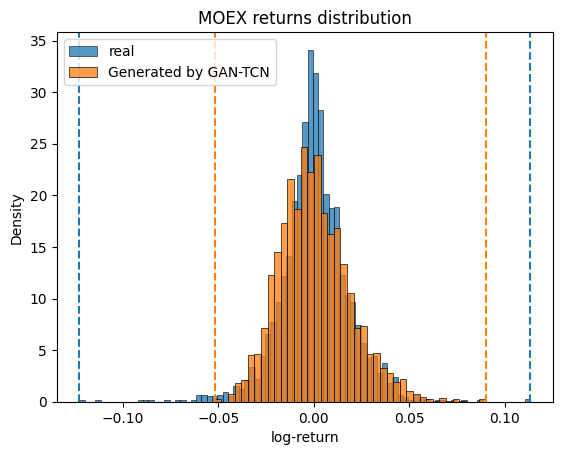

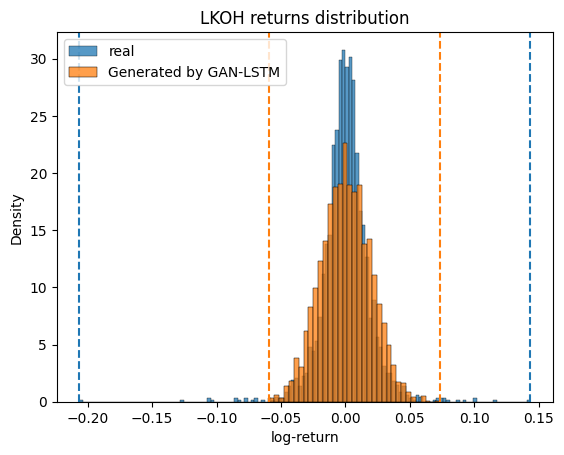

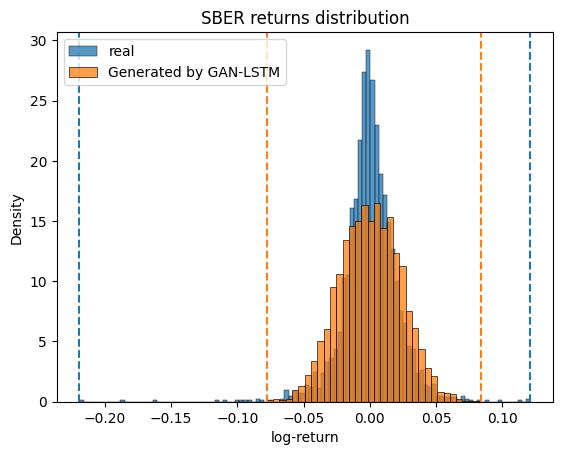

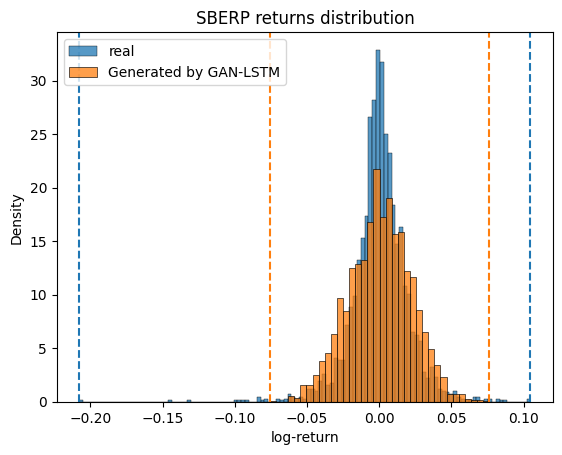

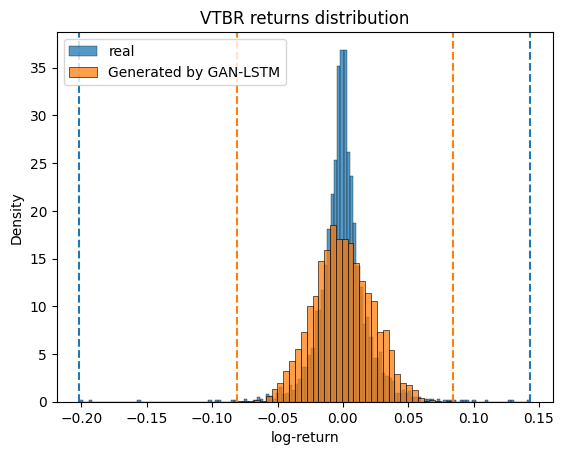

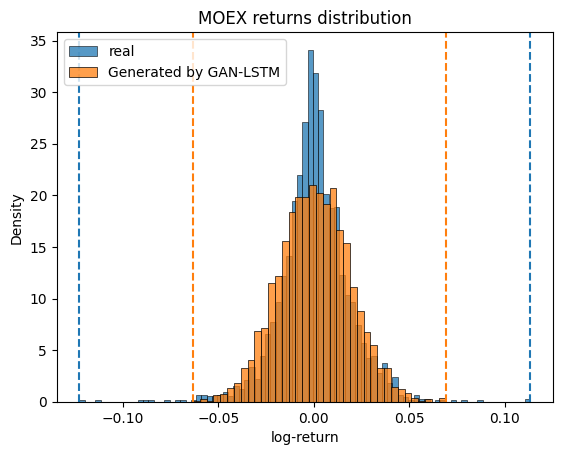

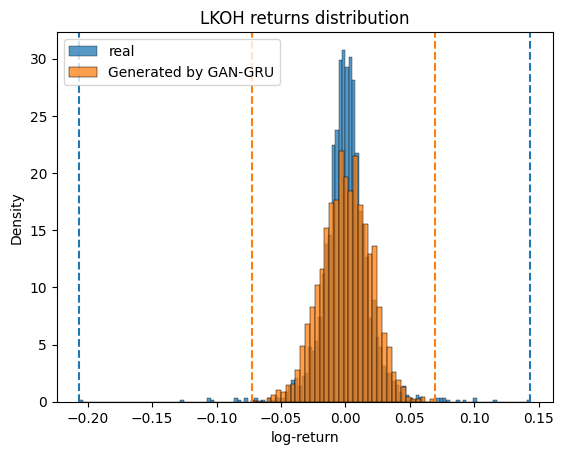

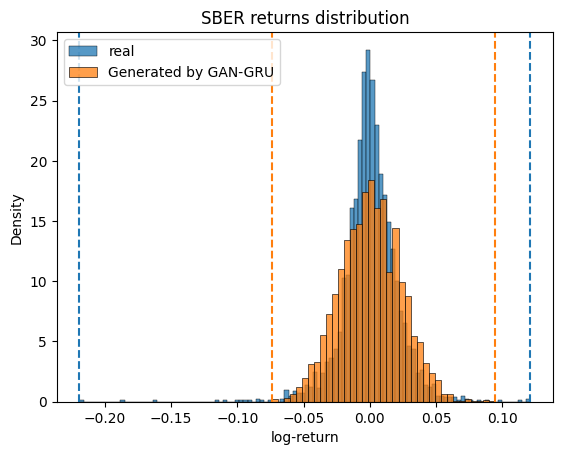

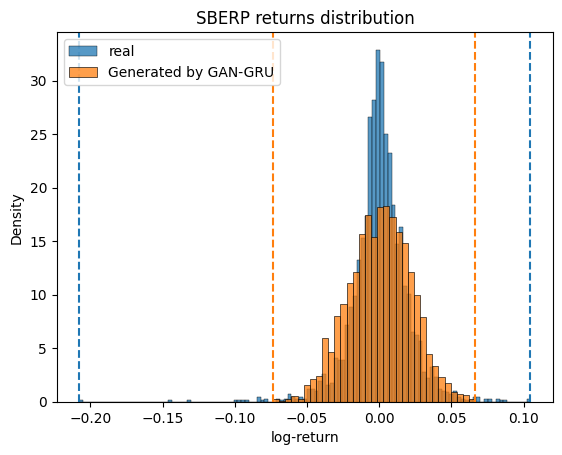

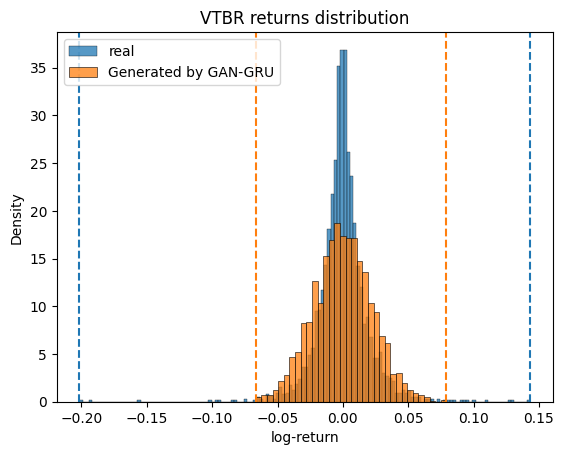

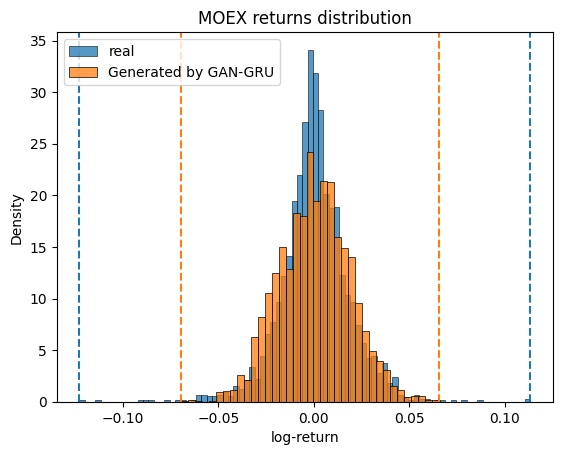

In [32]:
#TODO усреднения по генерациям нет!

tmp_df_returns_real = df_returns_real[df_returns_real.sum(axis=1) != df_returns_real.sum(axis=1).min()]
for arch in ARCHITECTURES:
    for col in df_returns_real.columns:
        # Plot returns distributions
        sns.histplot(tmp_df_returns_real[col], stat='density', label='real')
        sns.histplot(generated_returns[arch][0][col], stat='density', label=f'Generated by GAN-{arch}')
    
        # Plot real returns bounds
        plt.axvline(tmp_df_returns_real[col].min(), linestyle='dashed', color='C0')
        plt.axvline(tmp_df_returns_real[col].max(), linestyle='dashed', color='C0')
    
        # Plot fake returns bounds
        plt.axvline(generated_returns[arch][0][col].min(), linestyle='dashed', color='C1')
        plt.axvline(generated_returns[arch][0][col].max(), linestyle='dashed', color='C1')
    
        plt.xlabel('log-return')
        plt.legend(loc='upper left')
        plt.title(f'{col} returns distribution')
        plt.show()

In [33]:
from correlations import plot_correlation_matrix

plt.subplots(1, 2, figsize=(14, 5))

plt.subplot(1, 2, 1)
plot_correlation_matrix(df_returns_real.corr())
plt.title('Real')

plt.subplot(1, 2, 2)
plot_correlation_matrix(df_returns_fake.corr())
plt.title('Fake')

plt.show()

ModuleNotFoundError: No module named 'correlations'